<a href="https://colab.research.google.com/github/EMANFATIMA06/DATA-SCIENCE-AND-ANALYTICS-/blob/main/Customer%20Segmentation%20Using%20Unsupervised%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Customer Segmentation Using Unsupervised Learning***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("/content/Mall_Customers.csv")
df.rename(columns={
    "Annual Income (k$)": "AnnualIncome",
    "Spending Score (1-100)": "SpendingScore",
    "Genre": "Gender"
}, inplace=True)

In [4]:
print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df.describe())
print("Missing values:\n", df.isnull().sum())


Shape: (200, 5)
   CustomerID  Gender  Age  AnnualIncome  SpendingScore
0           1    Male   19            15             39
1           2    Male   21            15             81
2           3  Female   20            16              6
3           4  Female   23            16             77
4           5  Female   31            17             40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     200 non-null    int64 
 1   Gender         200 non-null    object
 2   Age            200 non-null    int64 
 3   AnnualIncome   200 non-null    int64 
 4   SpendingScore  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  AnnualIncome  SpendingScore
count  200.000000  200.000000    200.000000     200.000000
mean   100.500000   38.850000     60.560000      50.200000
std     57.

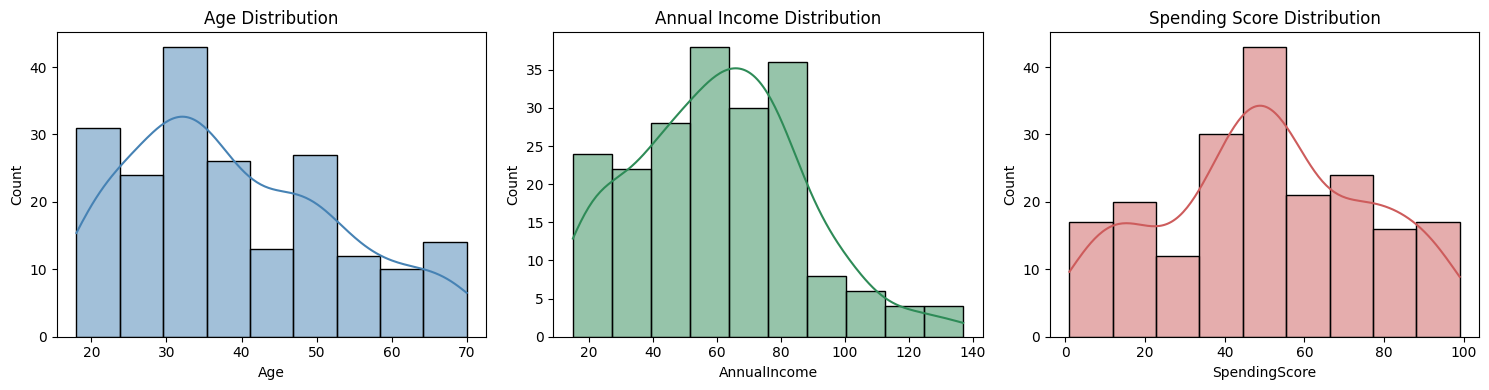

In [21]:
# 2. EXPLORATORY DATA ANALYSIS (EDA)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["Age"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution")
sns.histplot(df["AnnualIncome"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Annual Income Distribution")
sns.histplot(df["SpendingScore"], kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Spending Score Distribution")
plt.tight_layout()
plt.savefig("eda_distributions.png")
plt.show()

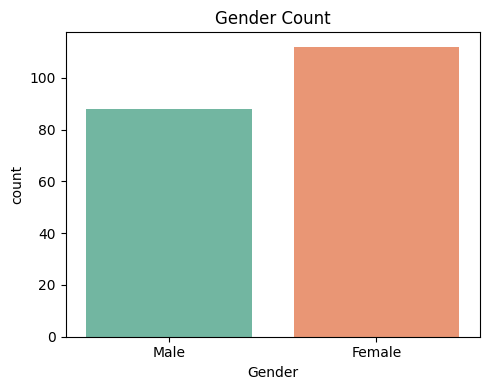

In [22]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Gender", hue="Gender", data=df, palette="Set2", legend=False)
plt.title("Gender Count")
plt.tight_layout()
plt.savefig("eda_gender_count.png")
plt.show()


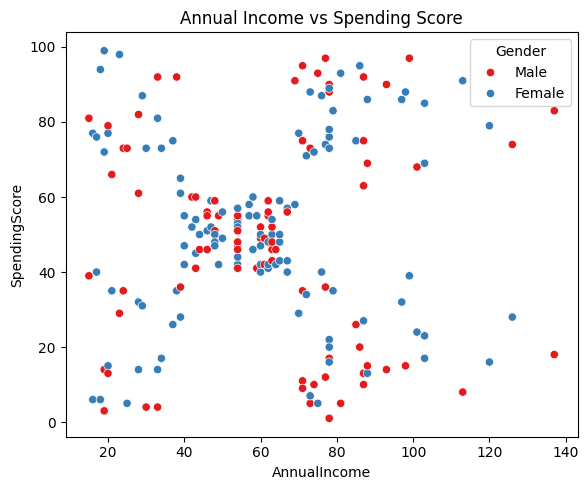

In [23]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x="AnnualIncome", y="SpendingScore", hue="Gender", data=df, palette="Set1")
plt.title("Annual Income vs Spending Score")
plt.tight_layout()
plt.savefig("eda_income_vs_spending.png")
plt.show()

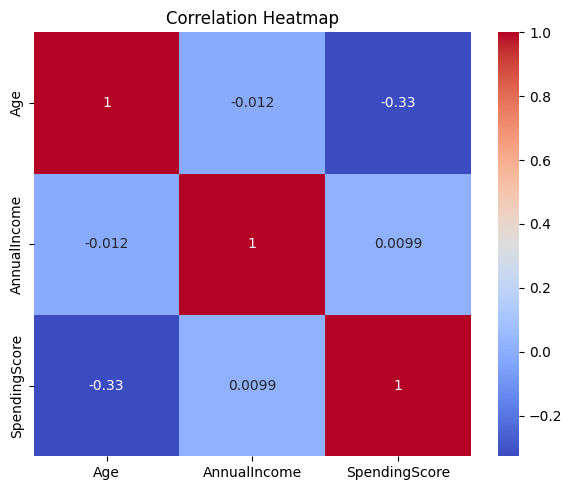

In [24]:
plt.figure(figsize=(6, 5))
corr = df[["Age", "AnnualIncome", "SpendingScore"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_correlation.png")
plt.show()

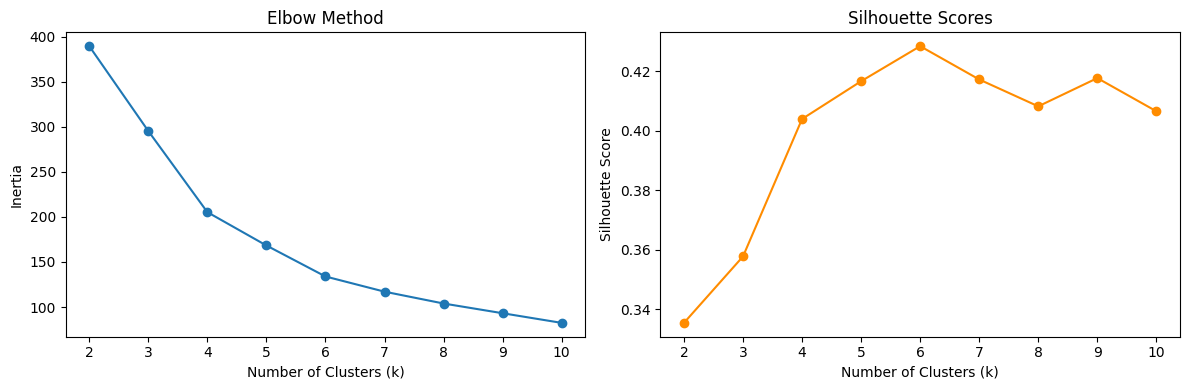


Best k by silhouette score: 6


In [25]:
# 3. FEATURE SCALING
features = ["Age", "AnnualIncome", "SpendingScore"]
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 4. ELBOW METHOD + SILHOUETTE SCORE TO FIND OPTIMAL K
inertias = []
sil_scores = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig("kmeans_k_selection.png")
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"\nBest k by silhouette score: {best_k}")

In [26]:
# 5. FINAL KMEANS MODEL (k=5, standard for this dataset)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster sizes:\n", df["Cluster"].value_counts().sort_index())
cluster_profile = df.groupby("Cluster")[features].mean().round(1)
print("\nCluster profile (mean values):\n", cluster_profile)


Cluster sizes:
 Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

Cluster profile (mean values):
           Age  AnnualIncome  SpendingScore
Cluster                                   
0        46.2          26.8           18.4
1        25.2          41.1           62.2
2        32.9          86.1           81.5
3        39.9          86.1           19.4
4        55.6          54.4           48.9


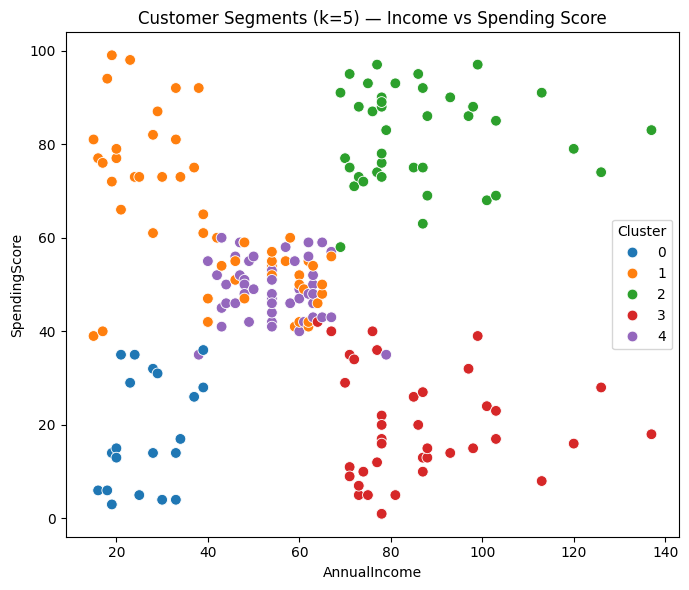

In [27]:
# 6. VISUALIZE CLUSTERS (RAW FEATURES)
plt.figure(figsize=(7, 6))
sns.scatterplot(x="AnnualIncome", y="SpendingScore", hue="Cluster", palette="tab10", data=df, s=60)
plt.title(f"Customer Segments (k={k}) — Income vs Spending Score")
plt.tight_layout()
plt.savefig("clusters_income_spending.png")
plt.show()


PCA explained variance ratio: [0.44266167 0.33308378]
Total variance explained: 77.57%


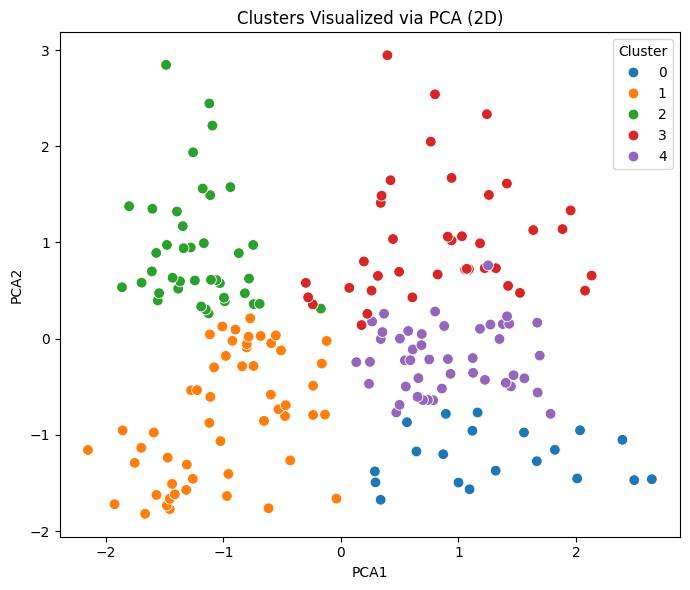

In [28]:
# 7. PCA VISUALIZATION (2D)
X_pca = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = X_pca[:, 0], X_pca[:, 1]

print(f"\nPCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(7, 6))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", palette="tab10", data=df, s=60)
plt.title("Clusters Visualized via PCA (2D)")
plt.tight_layout()
plt.savefig("clusters_pca.png")
plt.show()

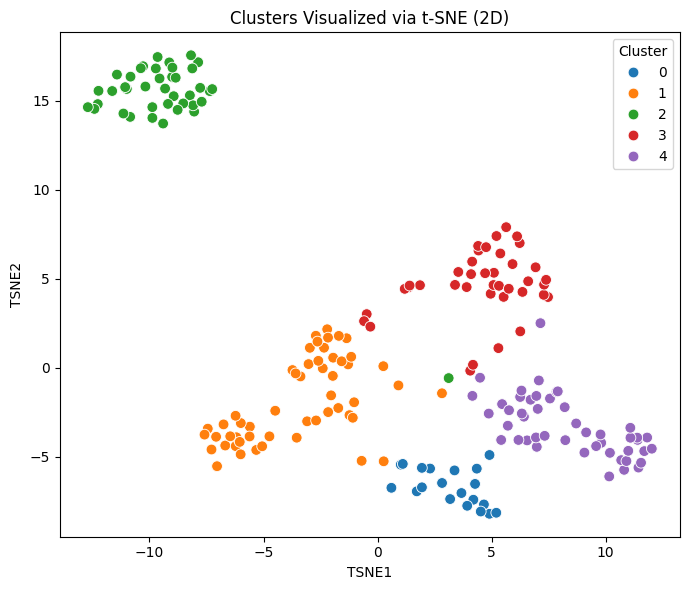

In [29]:
# 8. t-SNE VISUALIZATION (2D)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_scaled)
df["TSNE1"], df["TSNE2"] = X_tsne[:, 0], X_tsne[:, 1]

plt.figure(figsize=(7, 6))
sns.scatterplot(x="TSNE1", y="TSNE2", hue="Cluster", palette="tab10", data=df, s=60)
plt.title("Clusters Visualized via t-SNE (2D)")
plt.tight_layout()
plt.savefig("clusters_tsne.png")
plt.show()

In [30]:
#9. MARKETING STRATEGY PER SEGMENT
print("\n" + "=" * 70)
print("MARKETING STRATEGY SUGGESTIONS PER SEGMENT")
print("=" * 70)

strategy_map = {
    "high_income_high_spend": "VIP / premium segment: loyalty programs, early access to new "
                               "collections, exclusive events, premium upsells, personal shoppers.",
    "high_income_low_spend": "Price-insensitive but disengaged: needs re-engagement via "
                              "personalized offers, quality-focused marketing, and highlighting "
                              "brand prestige rather than discounts.",
    "low_income_high_spend": "Value-driven enthusiasts: target with discounts, buy-now-pay-later "
                              "options, flash sales, and loyalty point systems to sustain spend.",
    "low_income_low_spend": "Price-sensitive, low engagement: budget bundles, seasonal discount "
                             "campaigns, and low-cost entry offers to build engagement.",
    "average": "Mainstream/moderate segment: general seasonal promotions, email newsletters, "
               "and cross-sell recommendations; nurture toward higher spend with targeted campaigns."
}

income_median = df["AnnualIncome"].median()
spend_median = df["SpendingScore"].median()

for c in sorted(df["Cluster"].unique()):
    sub = df[df["Cluster"] == c]
    avg_age = sub["Age"].mean()
    avg_income = sub["AnnualIncome"].mean()
    avg_spend = sub["SpendingScore"].mean()

    if avg_income >= income_median and avg_spend >= spend_median:
        seg_type, label = "high_income_high_spend", "Premium Big Spenders"
    elif avg_income >= income_median and avg_spend < spend_median:
        seg_type, label = "high_income_low_spend", "Wealthy but Cautious"
    elif avg_income < income_median and avg_spend >= spend_median:
        seg_type, label = "low_income_high_spend", "Budget-Conscious Enthusiasts"
    elif avg_income < income_median and avg_spend < spend_median:
        seg_type, label = "low_income_low_spend", "Low Engagement / Budget Shoppers"
    else:
        seg_type, label = "average", "Average / Mainstream"

    print(f"\nCluster {c} — {label}  (n={len(sub)})")
    print(f"  Avg Age: {avg_age:.1f} | Avg Income: {avg_income:.1f}k | Avg Spending Score: {avg_spend:.1f}")
    print(f"  Strategy: {strategy_map[seg_type]}")

print("\nAll plots saved as PNG files. Segmented dataset saved to 'mall_customers_segmented.csv'.")



MARKETING STRATEGY SUGGESTIONS PER SEGMENT

Cluster 0 — Low Engagement / Budget Shoppers  (n=20)
  Avg Age: 46.2 | Avg Income: 26.8k | Avg Spending Score: 18.4
  Strategy: Price-sensitive, low engagement: budget bundles, seasonal discount campaigns, and low-cost entry offers to build engagement.

Cluster 1 — Budget-Conscious Enthusiasts  (n=54)
  Avg Age: 25.2 | Avg Income: 41.1k | Avg Spending Score: 62.2
  Strategy: Value-driven enthusiasts: target with discounts, buy-now-pay-later options, flash sales, and loyalty point systems to sustain spend.

Cluster 2 — Premium Big Spenders  (n=40)
  Avg Age: 32.9 | Avg Income: 86.1k | Avg Spending Score: 81.5
  Strategy: VIP / premium segment: loyalty programs, early access to new collections, exclusive events, premium upsells, personal shoppers.

Cluster 3 — Wealthy but Cautious  (n=39)
  Avg Age: 39.9 | Avg Income: 86.1k | Avg Spending Score: 19.4
  Strategy: Price-insensitive but disengaged: needs re-engagement via personalized offers, qua

***RECOMMENDATIONS:***
1. Prioritize the 'Premium Big Spenders' (Cluster 2) for revenue growth —
   they already spend heavily and have high income; retaining them via
   loyalty tiers and exclusive perks protects the most valuable revenue base.

2. 'Wealthy but Cautious' customers (Cluster 3) represent the biggest
   untapped opportunity — they have the income to spend more but aren't
   engaging. Personalized, quality-driven campaigns (not discounts) are
   more likely to convert them into big spenders.

3. 'Budget-Conscious Enthusiasts' (Cluster 1) are younger, high-spending
   despite lower income — ideal targets for installment plans, student
   discounts, and social-media-driven flash sales to keep loyalty early.

4. Low-engagement segments (Clusters 0 & 4) need low-cost entry campaigns
   (bundles, seasonal sales) to increase engagement gradually rather than
   aggressive upselling, which is unlikely to convert given spending habits.